<a href="https://colab.research.google.com/github/AtulMomre2327/Intro-to-Machine-Learning/blob/main/Linear_Regression_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <u> Implementing Multiple Linear Regression </u>

### <u> Objective </u>
* ### To predict the profit made by a startup on the basis of expenses incurred and the state where they operate

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Importing the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Toppers Acadmy Data/data/Machine Learning/Chapter 1:- ML Appetizer/Day 4/Copy of 50_Startups.csv')

In [ ]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [ ]:
df.shape

(50, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


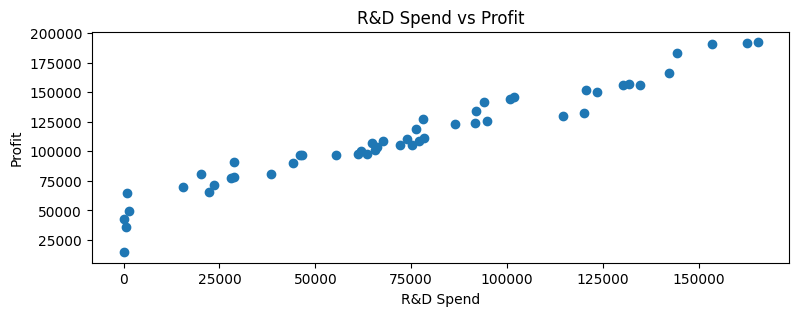

In [ ]:
plt.figure(figsize=(9,3))
plt.scatter(df['R&D Spend'],df['Profit'])
plt.title('R&D Spend vs Profit')
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.show()

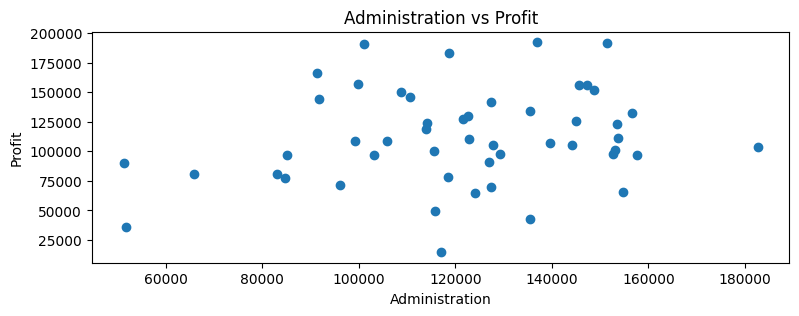

In [ ]:
plt.figure(figsize=(9,3))
plt.scatter(df['Administration'],df['Profit'])
plt.title('Administration vs Profit')
plt.xlabel('Administration')
plt.ylabel('Profit')
plt.show()

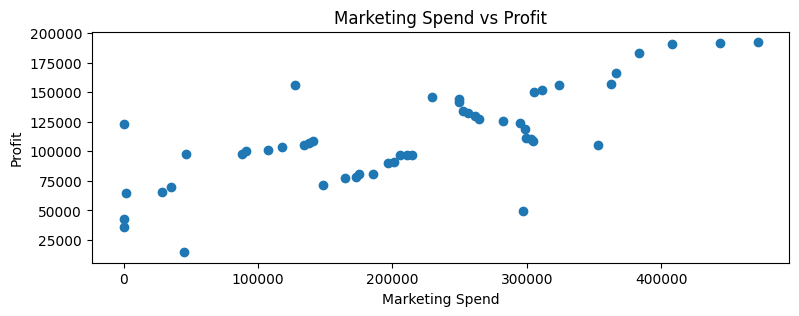

In [ ]:
plt.figure(figsize=(9,3))
plt.scatter(df['Marketing Spend'],df['Profit'])
plt.title('Marketing Spend vs Profit')
plt.xlabel('Marketing Spend')
plt.ylabel('Profit')
plt.show()

In [ ]:
df.groupby(['State'])['Profit'].mean()

,Profit
State,
California,103905.175294
Florida,118774.024375
New York,113756.446471


<Axes: xlabel='State'>

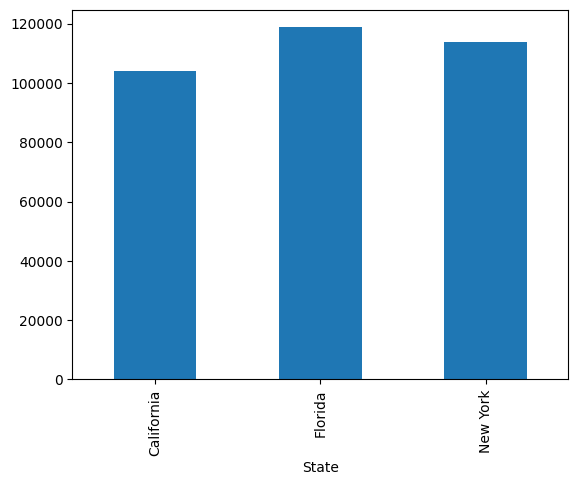

In [ ]:
df.groupby(['State'])['Profit'].mean().plot(kind = 'bar')

In [ ]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [ ]:
df['State'].head()

,State
0,New York
1,California
2,Florida
3,New York
4,Florida


In [ ]:
# Label encoding
State
  0
  1
  2
  0
  2

IndentationError: unexpected indent (1549326534.py, line 3)

In [ ]:
# column encoding
# State_New York    State California      state Florida
      1                     0                   0
      0                     1                   0
      0                     0                   1


In [ ]:
df['state_newyork'] = np.where(df['State'] == 'New York',1,0)
df['state_california'] = np.where(df['State'] == 'California',1,0)
df['state_florida'] = np.where(df['State'] == 'Florida',1,0)

In [ ]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit,state_newyork,state_california,state_florida
0,165349.20,136897.80,471784.10,New York,192261.83,1,0,0
1,162597.70,151377.59,443898.53,California,191792.06,0,1,0
2,153441.51,101145.55,407934.54,Florida,191050.39,0,0,1
3,144372.41,118671.85,383199.62,New York,182901.99,1,0,0
4,142107.34,91391.77,366168.42,Florida,166187.94,0,0,1


In [ ]:
df.drop(columns = ['State'],inplace = True)

In [ ]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,state_newyork,state_california,state_florida
0,165349.20,136897.80,471784.10,192261.83,1,0,0
1,162597.70,151377.59,443898.53,191792.06,0,1,0
2,153441.51,101145.55,407934.54,191050.39,0,0,1
3,144372.41,118671.85,383199.62,182901.99,1,0,0
4,142107.34,91391.77,366168.42,166187.94,0,0,1


In [ ]:
x = df.drop(columns = ['Profit'])
y = df['Profit']

In [ ]:
x.head()

,R&D Spend,Administration,Marketing Spend,state_newyork,state_california,state_florida
0,165349.20,136897.80,471784.10,1,0,0
1,162597.70,151377.59,443898.53,0,1,0
2,153441.51,101145.55,407934.54,0,0,1
3,144372.41,118671.85,383199.62,1,0,0
4,142107.34,91391.77,366168.42,0,0,1


In [ ]:
y.head()

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
x_train.head(2)

,R&D Spend,Administration,Marketing Spend,state_newyork,state_california,state_florida
12,93863.75,127320.38,249839.44,0,0,1
4,142107.34,91391.77,366168.42,0,0,1


In [ ]:
y_train.head(2)

,Profit
12,141585.52
4,166187.94


In [ ]:
x_test.head(2)

,R&D Spend,Administration,Marketing Spend,state_newyork,state_california,state_florida
13,91992.39,135495.07,252664.93,0,1,0
39,38558.51,82982.09,174999.30,0,1,0


In [ ]:
y_test.head(2)

,Profit
13,134307.35
39,81005.76


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
model.coef_

array([ 8.05630064e-01, -6.87878823e-02,  2.98554429e-02, -3.08272495e+02,
       -3.15260255e+02,  6.23532751e+02])

In [ ]:
x_train.head(1)

,R&D Spend,Administration,Marketing Spend,state_newyork,state_california,state_florida
12,93863.75,127320.38,249839.44,0,0,1


In [ ]:
y_train.head(1)

,Profit
12,141585.52


In [ ]:
train_pred = model.predict([[93863.75,127320.38,249839.44,0,0,1]])
print(train_pred)

[129287.25932268]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
train_pred = model.predict(x_train)
print(train_pred)

[129287.25932268 174098.25202593  91886.85822583 150220.99659018
 173623.19035613 156165.8448994   76521.47893708  56930.33870618
  44712.30856353 145679.58311298 155019.87822279 116405.47712515
 113471.56812687  86876.30432594  95418.08570239 191913.72740386
  62092.25276451 113876.00520382  98993.33790338 164246.36680449
  99560.6868471  136274.54962572  75324.02207359 187861.47839017
 115558.98201753 183805.40426655  58825.43932911  91390.89209793
 111197.68506735  74197.75183479 136305.24077721 115188.84018879
 129833.75780391  47329.63344538 116544.51129348 159597.70047234
  70875.8412832  148486.45402746  99143.4884277   71327.34640758]


In [ ]:
y_train.values

array([141585.52, 166187.94,  89949.14, 152211.77, 182901.99, 156122.51,
        77798.83,  49490.75,  42559.73, 129917.04, 149759.96, 126992.93,
       108552.04,  96712.8 ,  97483.56, 192261.83,  65200.33, 105008.31,
        96778.92, 156991.12, 101004.64, 144259.4 ,  90708.19, 191792.06,
       111313.02, 191050.39,  69758.98,  96479.51, 108733.99,  78239.91,
       146121.95, 110352.25, 124266.9 ,  14681.4 , 118474.03, 155752.6 ,
        71498.49, 132602.65, 103282.38,  81229.06])

In [ ]:
test_pred = model.predict(x_test)
print(test_pred)

[126362.87908255  84608.45383633  99677.49425146  46357.46068582
 128750.48288505  50912.41741878 109741.35032702 100643.24281647
  97599.27574593 113097.42524431]


In [ ]:
print(y_test.values)

[134307.35  81005.76  99937.59  64926.08 125370.37  35673.41 105733.54
 107404.34  97427.84 122776.86]


In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
print('Train mean_squared_error :-',mean_squared_error(y_train,train_pred))
print('Train mean_absolute_error :-',mean_absolute_error(y_train,train_pred))
print('Train mean_absolute_percentage_error :-',mean_absolute_percentage_error(y_train,train_pred)*100)
print('Train R2 score ',r2_score(y_train,train_pred))

Train mean_squared_error :- 79700060.08259319
Train mean_absolute_error :- 6662.656240897503
Train mean_absolute_percentage_error :- 10.947756972103429
Train R2 score  0.9537019995248526


In [ ]:
print('Test mean_squared_error :- ',mean_squared_error(y_test,test_pred))
print('Test mean_absolute_error :-',mean_absolute_error(y_test,test_pred))
print('Test mean_absolute_percentage_error :-',mean_absolute_percentage_error(y_test,test_pred)*100)
print('Test R2 score ',r2_score(y_test,test_pred))

Test mean_squared_error :-  82010363.0442354
Test mean_absolute_error :- 6961.477813250242
Test mean_absolute_percentage_error :- 10.278189896347753
Test R2 score  0.8987266414329448


In [ ]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']

In [ ]:
model = joblib.load('model.pkl')

In [ ]:
model.predict([[93863.75,127320.38,249839.44,0,0,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([129287.25932268])